R=array([[1.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
        0.   , 0.   ],
       [0.5  , 0.5  , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
        0.   , 0.   ],
       [0.125, 0.5  , 0.75 , 0.5  , 0.125, 0.   , 0.   , 0.   , 0.   ,
        0.   , 0.   ],
       [0.   , 0.   , 0.   , 0.   , 0.125, 0.5  , 0.75 , 0.5  , 0.125,
        0.   , 0.   ],
       [0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.125, 0.5  , 0.75 ,
        0.5  , 0.125],
       [0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
        0.5  , 0.5  ],
       [0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
        0.   , 1.   ]])


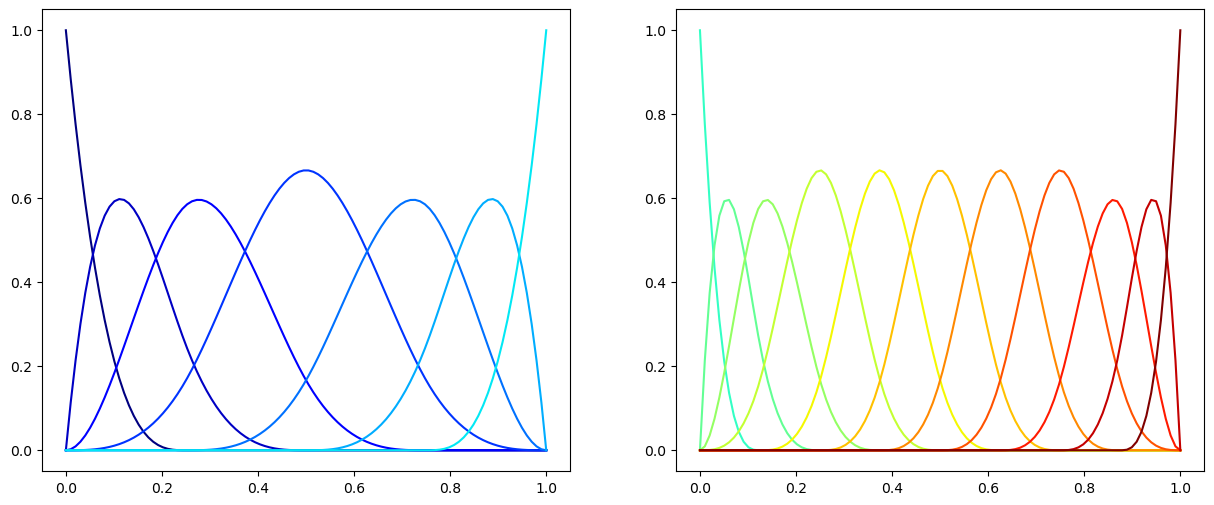

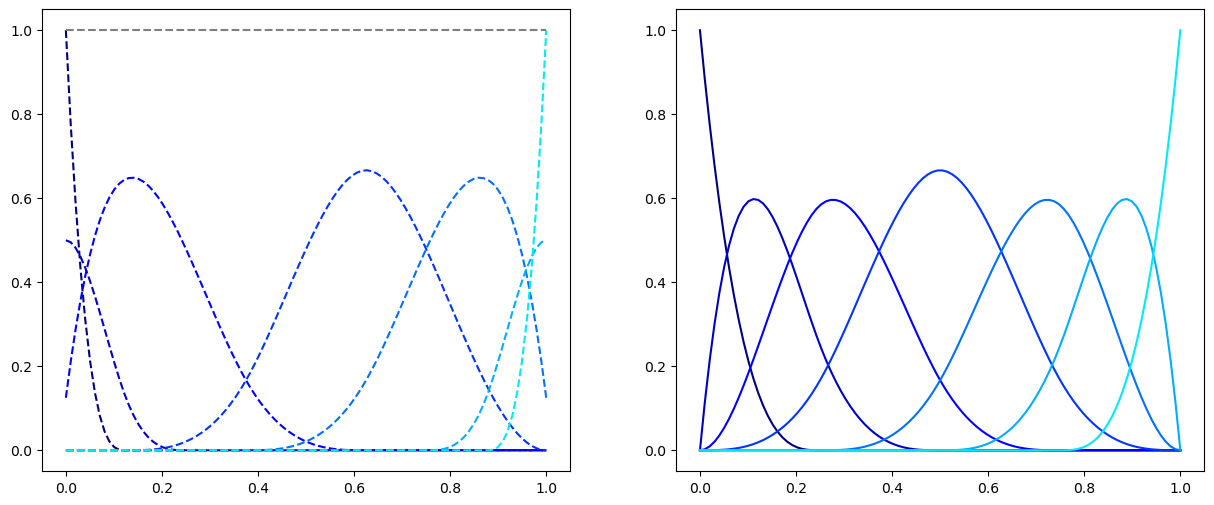

In [ ]:

"""
multigrid restrict / prolong from 3rd to 2nd order IGA 
"""

import numpy as np
import matplotlib.pyplot as plt

p = 3

def cubic_bernstein(xi):
    N  = np.array([
        (1 - xi)**3,
        3*xi*(1 - xi)**2,
        3*xi**2*(1 - xi),
        xi**3
    ])
    dN = np.array([
        -3*(1 - xi)**2,
        3*(1 - xi)**2 - 6*xi*(1 - xi),
        6*xi*(1 - xi) - 3*xi**2,
        3*xi**2
    ])
    return N, dN


u = np.linspace(0.0, 1.0, 100)

def build_basis(nxe):
    nglob = nxe+p # number of global basis functions
    colors = plt.cm.jet(np.linspace(0.0, 1.0, nglob))
    knots = [0.0]*(p+1) + [i/nxe for i in range(1,nxe)] + [1.0]*(p+1)
    global_basis = np.zeros((nglob, u.shape[0]))
    elem_conn = [
        [i, i+1, i+2, i+3] for i in range(nxe) # element connectivity
    ]
    for ielem in range(nxe):
    # for ielem in range(1):
        knot1, knot2 = knots[p+ielem], knots[p+ielem+1]
        # compute normalized coordinates in here
        xi = (u - knot1) / (knot2 - knot1)
        # zero out using mask products if xi not in 0, 1
        xi_mask = np.logical_and(xi >= 0.0, xi <= 1.0)
        # compute bernstein coefficients
        B, dB = cubic_bernstein(xi)

        first_elem  = (ielem == 0)
        second_elem = (ielem == 1)
        last_elem   = (ielem == nxe - 1)
        second_last = (ielem == nxe - 2)
        interior    = not (first_elem or second_elem or last_elem or second_last)

        if first_elem:
            N0 = 1.0 * B[0]
            N1 = 1.0 * B[1] + 0.5 * B[2] + 0.25 * B[3]
            N2 = 0.5 * B[2] + (7.0/12.0) * B[3]
            N3 = (1.0/6.0) * B[3]

        elif second_elem:
            N0 = 0.25 * B[0]
            N1 = (7.0/12.0)*B[0] + (2.0/3.0)*B[1] + (1.0/3.0)*B[2] + (1.0/6.0)*B[3]
            N2 = (1.0/6.0)*B[0] + (1.0/3.0)*B[1] + (2.0/3.0)*B[2] + (2.0/3.0)*B[3]
            N3 = (1.0/6.0) * B[3]

        elif second_last:
            # mirror of second
            N0 = (1.0/6.0) * B[0]
            N1 = (2.0/3.0)*B[0] + (2.0/3.0)*B[1] + (1.0/3.0)*B[2] + (1.0/6.0)*B[3]
            N2 = (1.0/6.0)*B[0] + (1.0/3.0)*B[1] + (2.0/3.0)*B[2] + (7.0/12.0)*B[3]
            N3 = 0.25 * B[3]

        elif last_elem:
            # mirror of first
            N0 = (1.0/6.0) * B[0]
            N1 = (7.0/12.0) * B[0] + 0.5 * B[1]
            N2 = 0.25 * B[0] + 0.5 * B[1] + 1.0 * B[2]
            N3 = 1.0 * B[3]

        else:  # interior
            N0 = (1.0/6.0) * B[0]

            N1 = (2.0/3.0)*B[0] + (2.0/3.0)*B[1] \
            + (1.0/3.0)*B[2] + (1.0/6.0)*B[3]

            N2 = (1.0/6.0)*B[0] + (1.0/3.0)*B[1] \
            + (2.0/3.0)*B[2] + (2.0/3.0)*B[3]

            N3 = (1.0/6.0) * B[3]

        # now add into these basis functions if they exist
        local_conn = elem_conn[ielem]
        g0, g1, g2, g3 = local_conn[0], local_conn[1], local_conn[2], local_conn[3]
        global_basis[g0] += N0 * xi_mask
        global_basis[g1] += N1 * xi_mask
        global_basis[g2] += N2 * xi_mask
        global_basis[g3] += N3 * xi_mask

    return global_basis



# ===========================================
# plot the fine and coarse global bases
# ===========================================

# construct fine and coarse bases
# nxe_f = 2
nxe_f = 8
# nxe_f = 16

nxe_c = nxe_f // 2
n_fine = nxe_f + p
n_coarse = nxe_c + p

fine_basis = build_basis(nxe_f)
coarse_basis = build_basis(nxe_c)

n_tot = n_fine + n_coarse
colors = plt.cm.jet(np.linspace(0.0, 1.0, n_tot))

# re-plot fine and coarse bases
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

for i in range(n_coarse):
    ax[0].plot(u, coarse_basis[i], color=colors[i])
for i in range(n_fine):
    ax[1].plot(u, fine_basis[i], color=colors[i+n_coarse])


# ===========================================
# restriction here..
# ===========================================

def restriction_p3_h2(nxe_f):
    _p = 3
    nxe_c = nxe_f // 2
    n_fine = nxe_f + _p
    n_coarse = nxe_c + _p

    R = np.zeros((n_coarse, n_fine))
    # counts = 1e-14 * np.ones_like(R)
    # counts = np.zeros(n_coarse)

    mask = np.array([1, 4, 6, 4, 1], dtype=float) / 8.0  # length 5

    # Interior mapping guess:
    # coarse i mostly lives over fine indices ~ 2*i (same “doubling” logic you used in p=2)
    for i in range(n_coarse):
        j0 = 2*i - 2  # shift so the 5-pt stencil sits sensibly (tweakable)
        for k in range(5):
            j = j0 + k
            if 0 <= j < n_fine:
                R[i, j] += mask[k]
                # counts[i, j] += 1.0
                # counts[i] += 1.0

    # normalize like your code does when overlaps accumulate / boundaries truncate
    # R /= counts
    R /= np.sum(R, axis=0)[None,:]
    # R /= np.sum(R, axis=1)
    # R /= np.sum(R, axis=1)[:, None]
    return R



R = restriction_p3_h2(nxe_f)
print(f"{R=}")
coarse_basis_v2 = np.dot(R, fine_basis)



fig, ax = plt.subplots(1, 2, figsize=(15, 6))
for i in range(n_coarse):
    ax[0].plot(u, coarse_basis_v2[i], '--', color=colors[i])
ax[0].plot(u, np.ones(100), '--', color="tab:gray")
for i in range(n_coarse):
    ax[1].plot(u, coarse_basis[i], color=colors[i])

In [ ]:
"""
do an optimizaiton problem to discover the 3rd to 2nd order IGA restriction operator
"""

def discover_R_rowwise_ls(fine_basis, coarse_basis, stencils):
    """
    stencils: list length n_coarse; each entry is a list/array of fine indices J_i
    """
    F = fine_basis   # (n_fine, nu)
    C = coarse_basis # (n_coarse, nu)
    n_coarse = C.shape[0]
    n_fine = F.shape[0]

    R = np.zeros((n_coarse, n_fine))
    A_full = F.T  # (nu, n_fine)

    for i in range(n_coarse):
        J = np.array(stencils[i], dtype=int)
        A = A_full[:, J]      # (nu, |J|)
        b = C[i, :].T         # (nu,)

        x, *_ = np.linalg.lstsq(A, b, rcond=1e-12)
        R[i, J] = x

    return R

def stencils_p3_h2(nxe_f):
    p = 3
    nxe_c = nxe_f // 2
    n_fine = nxe_f + p
    n_coarse = nxe_c + p

    stencils = []
    for i in range(n_coarse):
        # baseline anchor
        j0 = 2*i - 2
        J = list(range(j0, j0+5))  # 5-pt interior

        # expand/clip near boundaries
        if i < 3:
            J = list(range(0, 7))  # let boundary rows use more dofs
        if i > n_coarse - 4:
            J = list(range(n_fine-7, n_fine))

        # clip valid range
        J = [j for j in J if 0 <= j < n_fine]
        stencils.append(J)

    return stencils


SyntaxError: incomplete input (3671847647.py, line 1)